In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [39]:
import torch
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# 1. The Divine Fire: Checking if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

print("\n--- NumPy vs PyTorch Practice ---")

# 2. Creating a 2D array in NumPy (something you know)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])




















print(f"NumPy Array:\n{np_array} (Type: {type(np_array)})")

# 3. Forging a PyTorch Tensor from that NumPy array
py_tensor = torch.from_numpy(np_array)
print(f"PyTorch Tensor:\n{py_tensor} (Type: {type(py_tensor)})")

# 4. Sending your tensor to the GPU warrior
if torch.cuda.is_available():
    gpu_tensor = py_tensor.to(device)
    print(f"\nTensor successfully sent to GPU! Device property: {gpu_tensor.device}")

PyTorch Version: 2.10.0+cu128
Using device: cuda
GPU Model: Tesla T4

--- NumPy vs PyTorch Practice ---
NumPy Array:
[[1. 2.]
 [3. 4.]] (Type: <class 'numpy.ndarray'>)
PyTorch Tensor:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) (Type: <class 'torch.Tensor'>)

Tensor successfully sent to GPU! Device property: cuda:0


In [40]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        
        # --- ENCODER ---
        # Compressing is as follows : 784 -> 256 -> 64 ->latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim) # the bottleneck,we have made the latent dimension a variable((by default 32 unless we change))
        )
        
        # --- DECODER ---
        # Decompressing is as follows: latent_dim-> 64 ->256 ->  784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28) 
            #  no final activation here as our data is z-score normalized(x-mean)/sd 
            # it contains negative values and exceeds [-1, 1].
        )

    def forward(self, x):
        # Flattenning the image
        x = x.view(-1, 28 * 28)
        #input batch has a shape of [64, 1, 28, 28] (Batch Size, Channels, Height, Width). By using .view(-1, 28 * 28), we are telling PyTorch to multiply 28 by 28 to get 784 for the second dimension. For the first dimension (-1), it calculates whatever number is needed for it to work correctly PyTorch automatically preserves the batch size of 64, changing the shape to [64, 784].
        
        # Compress
        latent_vector = self.encoder(x)
        
        # Reconstruct
        reconstructed = self.decoder(latent_vector)
        
        # Reshape back to image dimensions (Batch, Channels, Height, Width)
        reconstructed = reconstructed.view(-1, 1, 28, 28)
        return reconstructed
Model_endc=Autoencoder().to(device)
print(Model_endc)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)


# BUILDING THE MODEL

mean of dataset:0.28604060411453247 std of dataset:0.3530242443084717
total no of training images: 60000
total no of testing images: 10000
number of training batches with 64 image per batch: 938


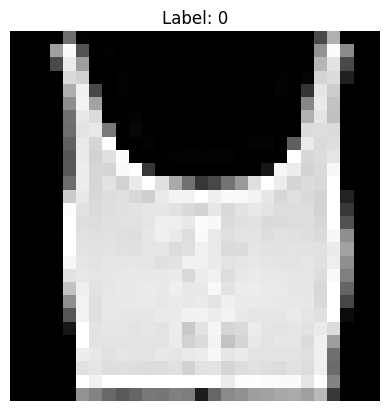

In [53]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plot
import numpy as np

#1. extracting the mean and std of the Fashion MNIST dataset
raw_data=torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
data=raw_data.data.float()/255.00
datamean=data.mean().item()
datasd=data.std().item()
print("mean of dataset:"+str(datamean),"std of dataset:"+str(datasd))

#they represent the global average pixel intensity and the spread of those intensities across the entire dataset when scaled to a [0, 1] range.



# 2. formatting the data and transforming it so that images can be fed in as data (Transforms)
# Neural networks prefer numbers clustered around 0 rather than large ranges (0-255 pixels).
transform = transforms.Compose([
    transforms.ToTensor(), # first step,converts the images to tensors(each pixel is now between 0 and 1)
    transforms.Normalize((datamean,), (datasd,)) # second step ,normalises(centres the data) mean=0.5,sd=0.5
])#(each pixel is now between -1 and 1),(x-mean)/sd,z-score
#without compose we have to manually apply this to every image.

# 2.downloading and seperating the training and testing FASHION -  MNIST data
# train=True gets the training set, train=False gets the test set
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)#root=data saves the images in the folder called data in the kaagle notebook
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)#from step 1,we bring in the transform


# 3. batching, as the loading the gpu with all the data at once reduces the effiency,gpu sits idle for most of the time.can lead to crashes.
# We feed the network 64 images at a time instead of all 60,000 at once to save memory and improve effiency.
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)#we shuffle the data to remove biases towards an one value,batch size is 64,at once 64 4d tensors are sent to the gpu
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)#no shuffling for testing 

print(f"total no of training images: {len(train_set)}")
print(f"total no of testing images: {len(test_set)}")
print(f"number of training batches with 64 image per batch: {len(train_loader)}")

# 4. visualizing a single batch
dataiter = iter(train_loader)#we made an iterable object ,we don't need to display all images so we didn;t use for loop
images, labels = next(dataiter)#we pushed the first object up

# un-normalize and displaying the first image of the batch
img = (images[0] *datasd) + datamean 
plot.imshow(np.squeeze(img.numpy()), cmap='gray')
#.numpy() changes pytorch tensorse back to numpy arrays,squeeze squeezes the 3d format to 2d(removes the dimension of 1) for plotting

plot.title(f"Label: {labels[0].item()}")#.item extracts the integer label value and displayes it,else it will be displayed as tenson(integer)
plot.axis('off')
plot.show()

# EXTRACTING THE DATA

--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 300] MSE_Loss: 0.258
  [Epoch 1, Batch 600] MSE_Loss: 0.156
  [Epoch 1, Batch 900] MSE_Loss: 0.136
Epoch [1/3] | Train MSE_Loss: 0.1809 | ,Val MSE_Loss: 0.1283
  [Epoch 2, Batch 300] MSE_Loss: 0.123
  [Epoch 2, Batch 600] MSE_Loss: 0.117
  [Epoch 2, Batch 900] MSE_Loss: 0.112
Epoch [2/3] | Train MSE_Loss: 0.1170 | ,Val MSE_Loss: 0.1105
  [Epoch 3, Batch 300] MSE_Loss: 0.108
  [Epoch 3, Batch 600] MSE_Loss: 0.105
  [Epoch 3, Batch 900] MSE_Loss: 0.103
Epoch [3/3] | Train MSE_Loss: 0.1050 | ,Val MSE_Loss: 0.1020
--- Training Completed ---


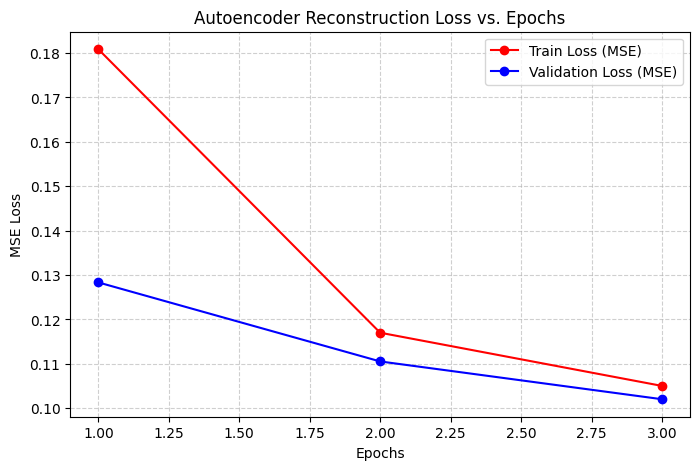

In [42]:
#  Baseline Training
import torch.optim as optim
loss_history=[]
train_acc_history = []
val_loss_history = []
val_acc_history = []
batch_loss_history=[]

# 1. The Strategy: Loss Function and Optimizer
# CrossEntropyLoss is standard for multi-class classification (digits 0-9)
criterion = nn.MSELoss()#to measure how physically different the reconstructed image is from the original,we use the mean squared error
# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer = optim.Adam(Model_endc.parameters(), lr=0.001)#lr=learning rate

# 2.Training Loop

#An Epoch is one complete pass through the entire library of 60,000 images,we run it 3 times because looking at the data just once isn't enough to memorize the complex patterns
epochs=3
print("--- Beginning of Training (Training the model) ---")
for epoch in range(3):
    Model_endc.train() # Set the model to training mode
    running_loss = 0.0
    correct_train=0
    total_train=0
    running_batch_loss=0.0
    
    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs = inputs.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = Model_endc(inputs)
        
        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs, inputs)

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Optimize (Update the models weights)
        optimizer.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        if i % 300 == 299:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] MSE_Loss: {running_batch_loss / 300:.3f}")
            batch_loss_history.append(running_batch_loss / 300)
            running_batch_loss = 0.0

      

    # calculating average loss for the epoch
    epoch_train_loss = running_loss / len(train_loader)

    
    loss_history.append(epoch_train_loss)
 


# --- VALIDATION PHASE ---
    Model_endc.eval() # Set model to evaluation mode 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = Model_endc(inputs)
            loss = criterion(outputs, inputs)
            
            running_val_loss += loss.item()
            
           
            
    epoch_val_loss = running_val_loss / len(test_loader)
    
    
    val_loss_history.append(epoch_val_loss)
 
    
    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train MSE_Loss: {epoch_train_loss:.4f} | ,"
          f"Val MSE_Loss: {epoch_val_loss:.4f}")

            

print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

# Plot Loss
epochs_range = range(1, epochs + 1)

plot.figure(figsize=(8, 5))
plot.plot(epochs_range, loss_history, label='Train Loss (MSE)', color='red', marker='o')
plot.plot(epochs_range, val_loss_history, label='Validation Loss (MSE)', color='blue', marker='o')
plot.title('Autoencoder Reconstruction Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('MSE Loss')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)
plot.show()

# TRAINING AND VALIDIATION

--- Visualizing Autoencoder Reconstructions ---


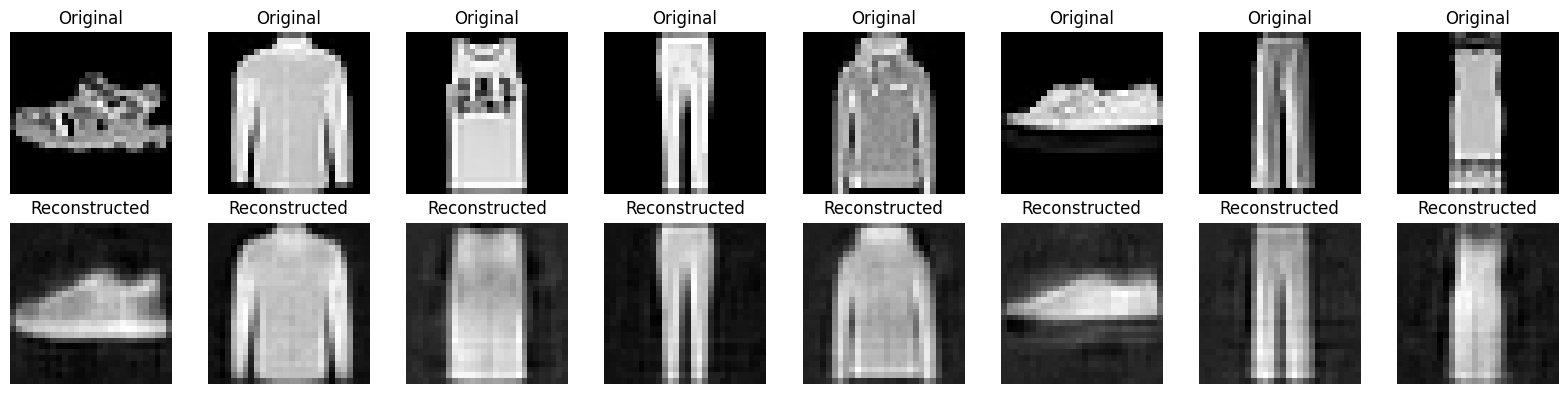

In [43]:
print("--- Visualizing Autoencoder Reconstructions ---")

#we are passing the images through the autoencoder
Model_endc.eval()
with torch.no_grad():
    images = images.to(device)
    reconstructed_images = Model_endc(images)

# data is moved back to cpu for plotting
images = images.cpu()
reconstructed_images = reconstructed_images.cpu()

# here we have choosed to display 8 images(8 orignal vs 8 reconstructed)
num_images = 8
plot.figure(figsize=(16, 4))

for i in range(num_images):
    #  ORIGINAL IMAGES IN TOP ROW
    plot.subplot(2, num_images, i + 1)
    
    # unnormalizing the original image
    orig_img = (images[i] * datasd) + datamean
    plot.imshow(np.squeeze(orig_img.numpy()), cmap='gray')
    
    plot.title("Original")
    plot.axis('off')

    #  RECONSTRUCTED IMAGES IN BOTTOM ROW
    plot.subplot(2, num_images, i + 1 + num_images)
    
    # unnormalize the reconstructed image
    recon_img = (reconstructed_images[i] * datasd) + datamean
    plot.imshow(np.squeeze(recon_img.numpy()), cmap='gray')
    
    plot.title("Reconstructed")
    plot.axis('off')

plot.tight_layout()
plot.show() 

# Visualising original vs reconstructed image

In [44]:
Model_endc_2=Autoencoder(latent_dim=16).to(device)
print(Model_endc_2)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)


# Experimenting with different latent dimensions(16)

--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 300] MSE_Loss: 0.263
  [Epoch 1, Batch 600] MSE_Loss: 0.159
  [Epoch 1, Batch 900] MSE_Loss: 0.141
Epoch [1/3] | Train MSE_Loss: 0.1856 | ,Val MSE_Loss: 0.1340
  [Epoch 2, Batch 300] MSE_Loss: 0.130
  [Epoch 2, Batch 600] MSE_Loss: 0.125
  [Epoch 2, Batch 900] MSE_Loss: 0.120
Epoch [2/3] | Train MSE_Loss: 0.1248 | ,Val MSE_Loss: 0.1194
  [Epoch 3, Batch 300] MSE_Loss: 0.116
  [Epoch 3, Batch 600] MSE_Loss: 0.114
  [Epoch 3, Batch 900] MSE_Loss: 0.114
Epoch [3/3] | Train MSE_Loss: 0.1145 | ,Val MSE_Loss: 0.1130
--- Training Completed ---


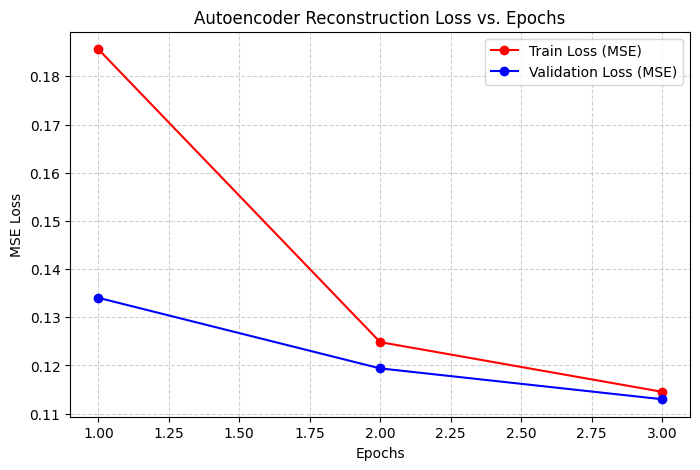

In [45]:
#  Baseline Training

loss_history_2=[]

val_loss_history_2 = []

batch_loss_history_2=[]

# 1. The Strategy: Loss Function and Optimizer
# CrossEntropyLoss is standard for multi-class classification (digits 0-9)
criterion = nn.MSELoss()#to measure how physically different the reconstructed image is from the original,we use the mean squared error
# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer_2 = optim.Adam(Model_endc_2.parameters(), lr=0.001)#lr=learning rate

# 2.Training Loop

#An Epoch is one complete pass through the entire library of 60,000 images,we run it 3 times because looking at the data just once isn't enough to memorize the complex patterns
epochs=3
print("--- Beginning of Training (Training the model) ---")
for epoch in range(3):
    Model_endc_2.train() # Set the model to training mode
    running_loss = 0.0
    correct_train=0
    total_train=0
    running_batch_loss=0.0
    
    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs = inputs.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer_2.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = Model_endc_2(inputs)
        
        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs, inputs)

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Optimize (Update the models weights)
        optimizer_2.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        if i % 300 == 299:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] MSE_Loss: {running_batch_loss / 300:.3f}")
            batch_loss_history_2.append(running_batch_loss / 300)
            running_batch_loss = 0.0

      

    # calculating average loss for the epoch
    epoch_train_loss = running_loss / len(train_loader)

    
    loss_history_2.append(epoch_train_loss)
 


# --- VALIDATION PHASE ---
    Model_endc_2.eval() # Set model to evaluation mode 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = Model_endc_2(inputs)
            loss = criterion(outputs, inputs)
            
            running_val_loss += loss.item()
            
           
            
    epoch_val_loss = running_val_loss / len(test_loader)
    
    
    val_loss_history_2.append(epoch_val_loss)
 
    
    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train MSE_Loss: {epoch_train_loss:.4f} | ,"
          f"Val MSE_Loss: {epoch_val_loss:.4f}")

            

print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

# Plot Loss
epochs_range = range(1, epochs + 1)

plot.figure(figsize=(8, 5))
plot.plot(epochs_range, loss_history_2, label='Train Loss (MSE)', color='red', marker='o')
plot.plot(epochs_range, val_loss_history_2, label='Validation Loss (MSE)', color='blue', marker='o')
plot.title('Autoencoder Reconstruction Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('MSE Loss')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)
plot.show()

--- Visualizing Autoencoder Reconstructions ---


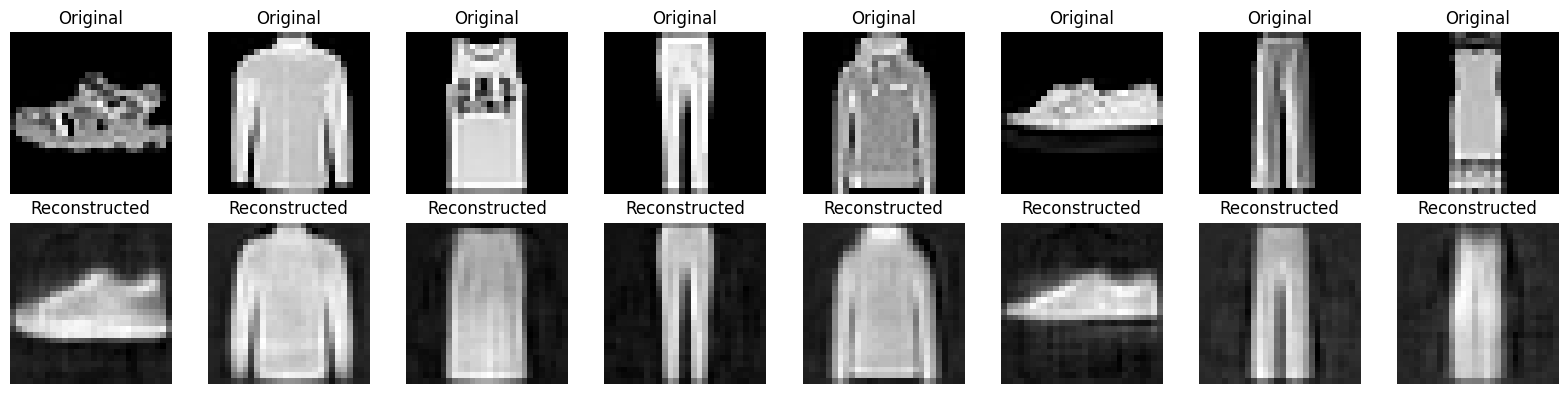

In [46]:
print("--- Visualizing Autoencoder Reconstructions ---")

#we are passing the images through the autoencoder
Model_endc_2.eval()
with torch.no_grad():
    images = images.to(device)
    reconstructed_images_2 = Model_endc_2(images)

# data is moved back to cpu for plotting
images = images.cpu()
reconstructed_images_2 = reconstructed_images_2.cpu()

# here we have choosed to display 8 images(8 orignal vs 8 reconstructed)
num_images = 8
plot.figure(figsize=(16, 4))

for i in range(num_images):
    #  ORIGINAL IMAGES IN TOP ROW
    plot.subplot(2, num_images, i + 1)
    
    # unnormalizing the original image
    orig_img = (images[i] * datasd) + datamean
    plot.imshow(np.squeeze(orig_img.numpy()), cmap='gray')
    
    plot.title("Original")
    plot.axis('off')

    #  RECONSTRUCTED IMAGES IN BOTTOM ROW
    plot.subplot(2, num_images, i + 1 + num_images)
    
    # unnormalize the reconstructed image
    recon_img = (reconstructed_images_2[i] * datasd) + datamean
    plot.imshow(np.squeeze(recon_img.numpy()), cmap='gray')
    
    plot.title("Reconstructed")
    plot.axis('off')

plot.tight_layout()
plot.show() 

In [47]:
Model_endc_3=Autoencoder(latent_dim=64).to(device)
print(Model_endc_3)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)


# Experimenting with different latent dimensions(64)

--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 300] MSE_Loss: 0.259
  [Epoch 1, Batch 600] MSE_Loss: 0.153
  [Epoch 1, Batch 900] MSE_Loss: 0.131
Epoch [1/3] | Train MSE_Loss: 0.1785 | ,Val MSE_Loss: 0.1248
  [Epoch 2, Batch 300] MSE_Loss: 0.118
  [Epoch 2, Batch 600] MSE_Loss: 0.111
  [Epoch 2, Batch 900] MSE_Loss: 0.106
Epoch [2/3] | Train MSE_Loss: 0.1112 | ,Val MSE_Loss: 0.1037
  [Epoch 3, Batch 300] MSE_Loss: 0.101
  [Epoch 3, Batch 600] MSE_Loss: 0.099
  [Epoch 3, Batch 900] MSE_Loss: 0.096
Epoch [3/3] | Train MSE_Loss: 0.0985 | ,Val MSE_Loss: 0.0943
--- Training Completed ---


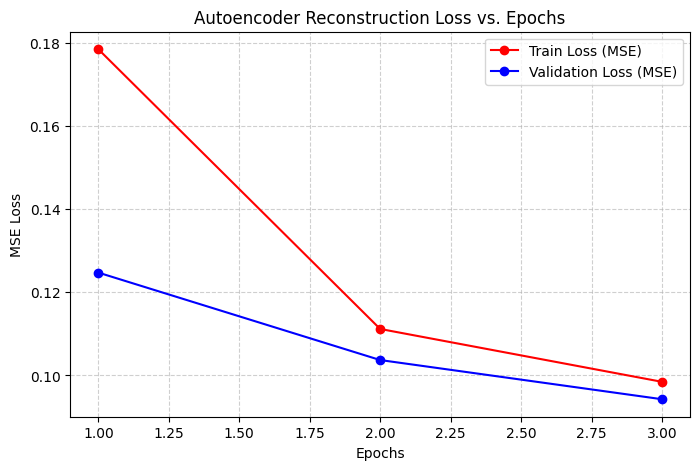

In [48]:
#  Baseline Training

loss_history_3=[]

val_loss_history_3 = []

batch_loss_history_3=[]

# 1. The Strategy: Loss Function and Optimizer
# CrossEntropyLoss is standard for multi-class classification (digits 0-9)
criterion = nn.MSELoss()#to measure how physically different the reconstructed image is from the original,we use the mean squared error
# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer_3 = optim.Adam(Model_endc_3.parameters(), lr=0.001)#lr=learning rate

# 2.Training Loop

#An Epoch is one complete pass through the entire library of 60,000 images,we run it 3 times because looking at the data just once isn't enough to memorize the complex patterns
epochs=3
print("--- Beginning of Training (Training the model) ---")
for epoch in range(3):
    Model_endc_3.train() # Set the model to training mode
    running_loss = 0.0
    correct_train=0
    total_train=0
    running_batch_loss=0.0
    
    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs = inputs.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer_3.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = Model_endc_3(inputs)
        
        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs, inputs)

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Optimize (Update the models weights)
        optimizer_3.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        if i % 300 == 299:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] MSE_Loss: {running_batch_loss / 300:.3f}")
            batch_loss_history_3.append(running_batch_loss / 300)
            running_batch_loss = 0.0

      

    # calculating average loss for the epoch
    epoch_train_loss = running_loss / len(train_loader)

    
    loss_history_3.append(epoch_train_loss)
 


# --- VALIDATION PHASE ---
    Model_endc_3.eval() # Set model to evaluation mode 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = Model_endc_3(inputs)
            loss = criterion(outputs, inputs)
            
            running_val_loss += loss.item()
            
           
            
    epoch_val_loss = running_val_loss / len(test_loader)
    
    
    val_loss_history_3.append(epoch_val_loss)
 
    
    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train MSE_Loss: {epoch_train_loss:.4f} | ,"
          f"Val MSE_Loss: {epoch_val_loss:.4f}")

            

print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

# Plot Loss
epochs_range = range(1, epochs + 1)

plot.figure(figsize=(8, 5))
plot.plot(epochs_range, loss_history_3, label='Train Loss (MSE)', color='red', marker='o')
plot.plot(epochs_range, val_loss_history_3, label='Validation Loss (MSE)', color='blue', marker='o')
plot.title('Autoencoder Reconstruction Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('MSE Loss')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)
plot.show()

--- Visualizing Autoencoder Reconstructions ---


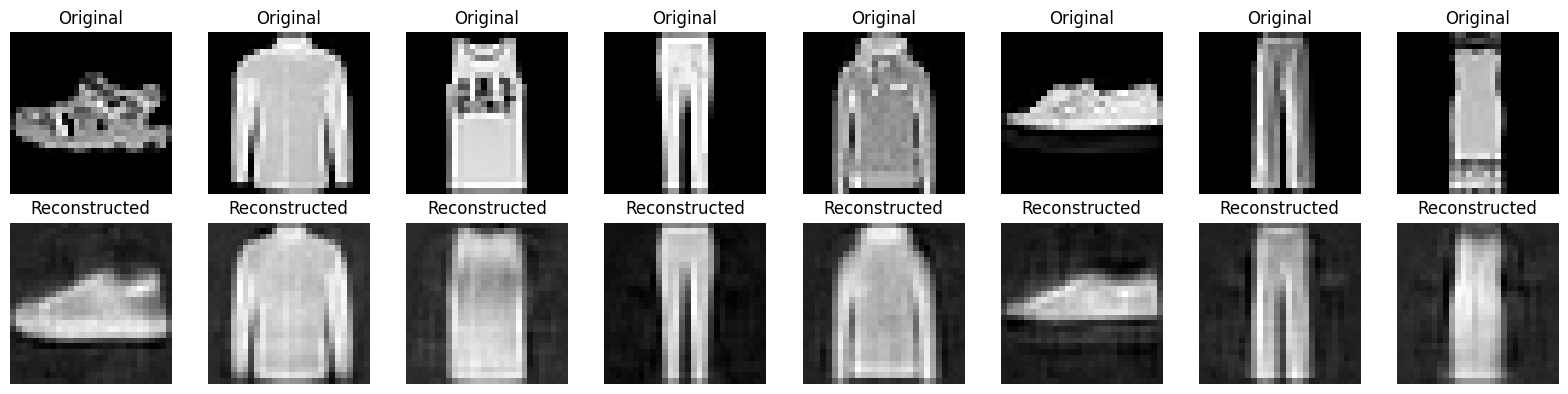

In [49]:
print("--- Visualizing Autoencoder Reconstructions ---")

#we are passing the images through the autoencoder
Model_endc_3.eval()
with torch.no_grad():
    images = images.to(device)
    reconstructed_images_3 = Model_endc_3(images)

# data is moved back to cpu for plotting
images = images.cpu()
reconstructed_images_3 = reconstructed_images_3.cpu()

# here we have choosed to display 8 images(8 orignal vs 8 reconstructed)
num_images = 8
plot.figure(figsize=(16, 4))

for i in range(num_images):
    #  ORIGINAL IMAGES IN TOP ROW
    plot.subplot(2, num_images, i + 1)
    
    # unnormalizing the original image
    orig_img = (images[i] * datasd) + datamean
    plot.imshow(np.squeeze(orig_img.numpy()), cmap='gray')
    
    plot.title("Original")
    plot.axis('off')

    #  RECONSTRUCTED IMAGES IN BOTTOM ROW
    plot.subplot(2, num_images, i + 1 + num_images)
    
    # unnormalize the reconstructed image
    recon_img = (reconstructed_images_3[i] * datasd) + datamean
    plot.imshow(np.squeeze(recon_img.numpy()), cmap='gray')
    
    plot.title("Reconstructed")
    plot.axis('off')

plot.tight_layout()
plot.show()

--- Visualizing Compression Quality: 16 vs 32 vs 64 ---


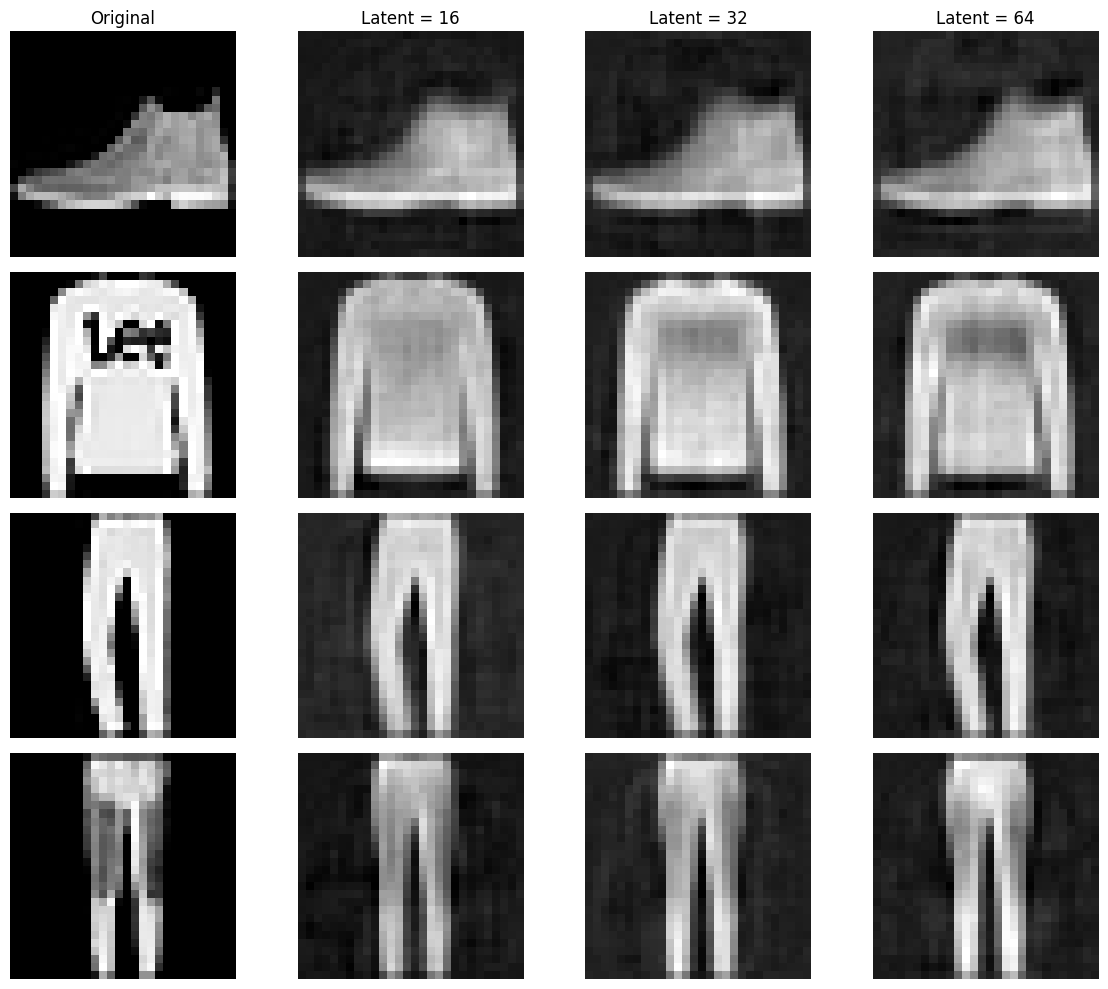

In [51]:


print("--- Visualizing Compression Quality: 16 vs 32 vs 64 ---")

# 1.we  Grab 1 batch of images
dataiter = iter(test_loader)
images, _ = next(dataiter)

# 2. Pass the excat same images through all three models simultaneously
Model_endc_2.eval() # Latent_dim = 16 
Model_endc.eval()   # Latent_dim = 32 
Model_endc_3.eval() # Latent_dim =  64

with torch.no_grad():
    images_gpu = images.to(device)
    recon_16 = Model_endc_2(images_gpu).cpu()
    recon_32 = Model_endc(images_gpu).cpu()
    recon_64 = Model_endc_3(images_gpu).cpu() 

images = images.cpu()

# 3. Plotting Setup (we look at 4 different clothing items)
num_images = 4
plot.figure(figsize=(12, 10)) # Taller figure for 4 rows

for i in range(num_images):
    # --- Column 1: original image -------------------------
    plot.subplot(num_images, 4, i * 4 + 1)
    orig_img = (images[i] * datasd) + datamean
    plot.imshow(np.squeeze(orig_img.numpy()), cmap='gray')
    if i == 0: plot.title("Original")
    plot.axis('off')

    # --- Column 2: Latent_dim 16 -------------------------
    plot.subplot(num_images, 4, i * 4 + 2)
    r16_img = (recon_16[i] * datasd) + datamean
    plot.imshow(np.squeeze(r16_img.numpy()), cmap='gray')
    if i == 0: plot.title("Latent = 16")
    plot.axis('off')

    # --- Column 3: Latent_dim = 32(baseline) -------------
    plot.subplot(num_images, 4, i * 4 + 3)
    r32_img = (recon_32[i] * datasd) + datamean
    plot.imshow(np.squeeze(r32_img.numpy()), cmap='gray')
    if i == 0: plot.title("Latent = 32")
    plot.axis('off')

    #--- Column 4: Latent_dim = 64 -----------------------
    plot.subplot(num_images, 4, i * 4 + 4)
    r64_img = (recon_64[i] * datasd) + datamean
    plot.imshow(np.squeeze(r64_img.numpy()), cmap='gray')
    if i == 0: plot.title("Latent = 64")
    plot.axis('off')

plot.tight_layout()
plot.show()

# Effect of latent_dimension on the reconstructed image

--- Plotting Autoencoder Bottleneck Comparison ---


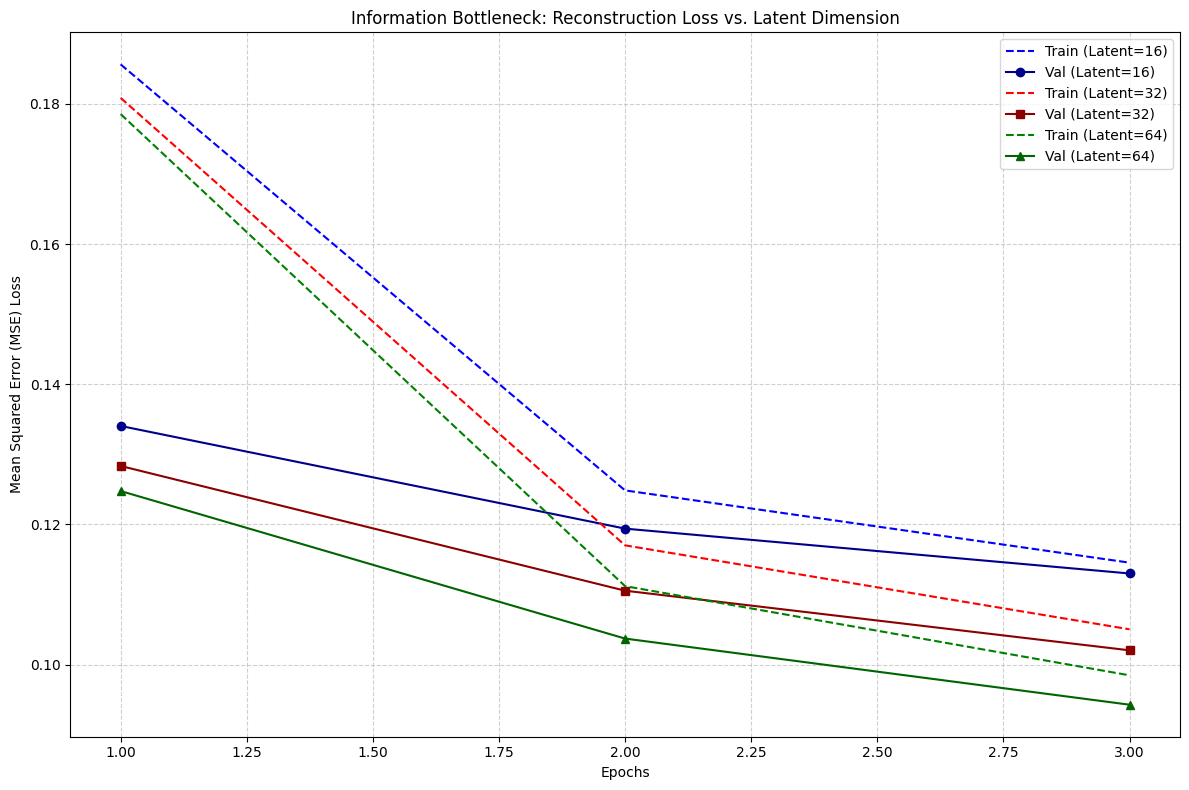

In [52]:


print("--- Plotting Autoencoder Bottleneck Comparison ---")

epochs_range = range(1, epochs + 1)
plot.figure(figsize=(12, 8))

# ---  Highest compression (Latent = 16) ---
# We expect this to have the HIGHEST loss (worst performance)
plot.plot(epochs_range, loss_history_2, label='Train (Latent=16)', color='blue', linestyle='--')
plot.plot(epochs_range, val_loss_history_2, label='Val (Latent=16)', color='darkblue', marker='o')

# ---Baseline model (Latent = 32) ---
# We expect this to be in the middle
plot.plot(epochs_range, loss_history, label='Train (Latent=32)', color='red', linestyle='--')
plot.plot(epochs_range, val_loss_history, label='Val (Latent=32)', color='darkred', marker='s')

# ---Lowest  Compression(Latent = 64) ---
# We expect this to have the LOWEST loss (best performance)
plot.plot(epochs_range, loss_history_3, label='Train (Latent=64)', color='green', linestyle='--')
plot.plot(epochs_range, val_loss_history_3, label='Val (Latent=64)', color='darkgreen', marker='^')

# --- graph ---
plot.title('Information Bottleneck: Reconstruction Loss vs. Latent Dimension')
plot.xlabel('Epochs')
plot.ylabel('Mean Squared Error (MSE) Loss')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

plot.tight_layout()
plot.show()

# Graph comparision of different latent dimensions(16 vs 32 vs 64)